In [1]:
using LinearAlgebra
using Distributed

println("hostname = ", readchomp(`hostname`))
println("threads = ", Threads.nthreads())
println("workers = ", nworkers())
println("BLAS threads = ", BLAS.get_num_threads())


hostname = wifi-secure4-376.sri.ucl.ac.be
threads = 1
workers = 1
BLAS threads = 4


In [2]:
using Eliashberg
using CairoMakie

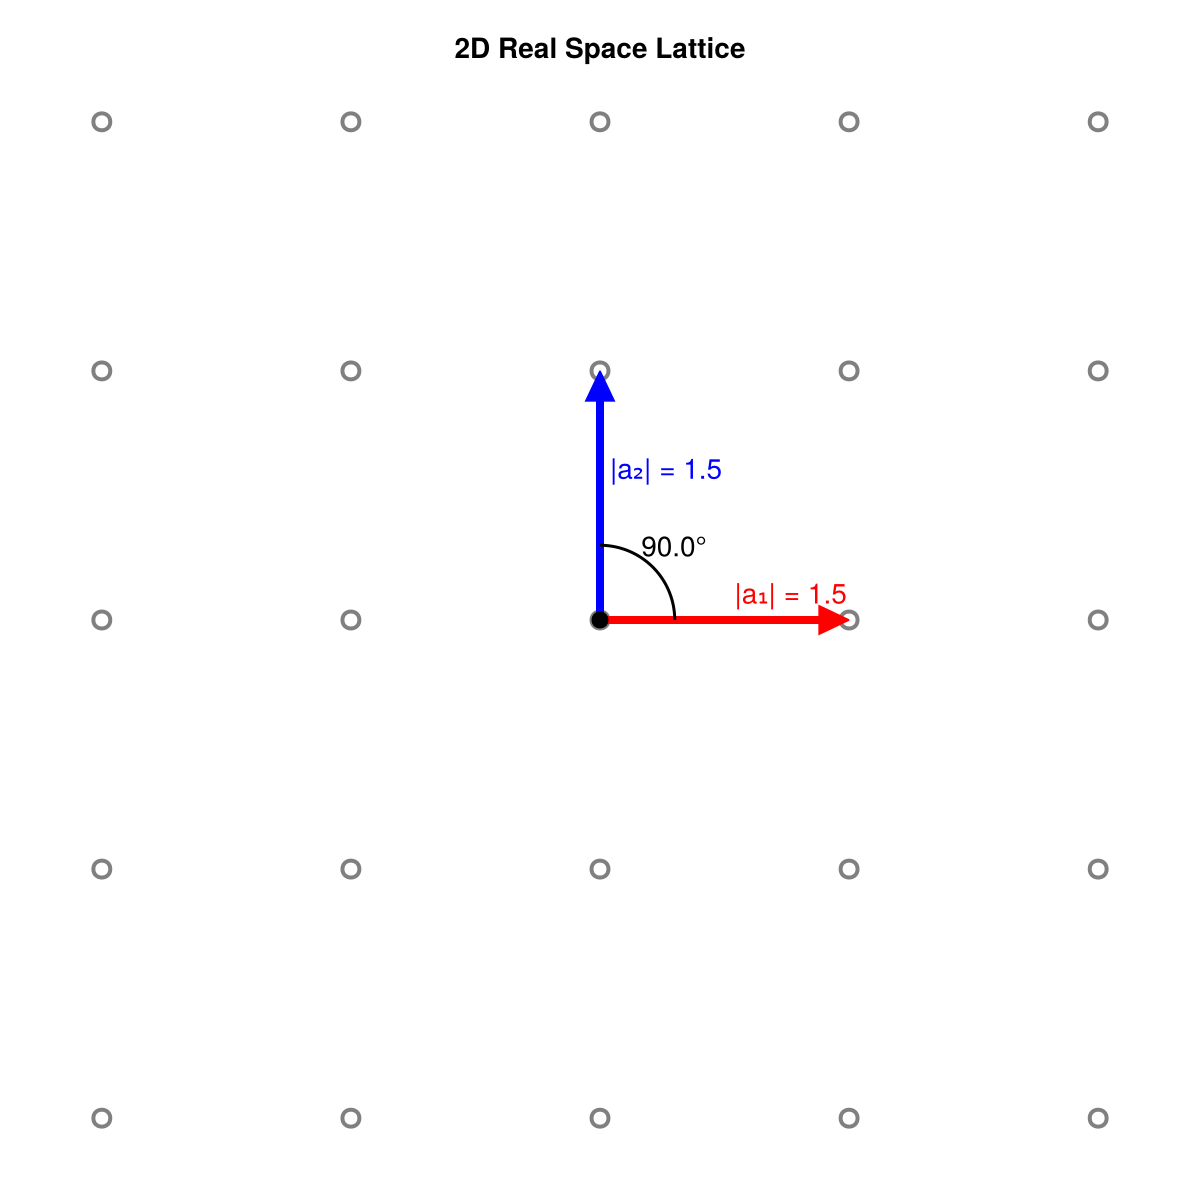

In [3]:
# 老的 Bravais lattice 接口仍然可用
lattice = SquareLattice(1.5)
kgrid = generate_reciprocal_lattice(lattice, 20, 20)

visualize_lattice(lattice)


In [4]:
# 统一的 QE 入口：先查 ibrav 的元信息
ibrav(2)


IBrav 2: Cubic F (fcc)
  Signature: ibrav(2, a; ...)
  Positional:
    - a: reference lattice length
  Required keywords: none
  Optional keywords:
    - celldm2: b / a
    - celldm3: c / a
    - celldm4: cosine parameter used by this `ibrav` branch
    - celldm5: cosine parameter used by this `ibrav` branch
    - celldm6: cosine parameter used by this `ibrav` branch
  Example: ibrav(2, a)

In [8]:
# 再直接用 ibrav(id, a; kwargs...) 构造 primitive cell
cell = ibrav(2, 5.43)
cell.vectors


3×3 StaticArraysCore.SMatrix{3, 3, Float64, 9} with indices SOneTo(3)×SOneTo(3):
 -2.715  0.0    -2.715
  0.0    2.715   2.715
  2.715  2.715   0.0

In [9]:
# 直接从 cell + basis atoms 构造 Crystal
# 默认把位置当作 scaled / fractional coordinates
crystal = Crystal(
    cell,
    [
        :Si => [0.0, 0.0, 0.0],
        :Si => [0.25, 0.25, 0.25],
    ],
)

scaled_positions(crystal), positions(crystal)


(StaticArraysCore.SVector{3, Float64}[[0.0, 0.0, 0.0], [0.25, 0.25, 0.25]], StaticArraysCore.SVector{3, Float64}[[0.0, 0.0, 0.0], [-1.3575, 1.3575, 1.3575]])

In [10]:
# ASE 风格继续 append atom
append_atom!(crystal, :Ge => [0.5, 0.5, 0.5])
crystal.atomic_symbols, scaled_positions(crystal)


([:Si, :Si, :Ge], StaticArraysCore.SVector{3, Float64}[[0.0, 0.0, 0.0], [0.25, 0.25, 0.25], [0.5, 0.5, 0.5]])

In [11]:
# 直接整体替换 scaled positions
set_scaled_positions!(crystal, [
    [0.0, 0.0, 0.0],
    [0.25, 0.25, 0.25],
    [0.5, 0.5, 0.5],
])

scaled_positions(crystal)


3-element Vector{StaticArraysCore.SVector{3, Float64}}:
 [0.0, 0.0, 0.0]
 [0.25, 0.25, 0.25]
 [0.5, 0.5, 0.5]

In [12]:
# set_cell! 默认保持 Cartesian positions 不变
# 相当于 ASE 的 set_cell(...; scale_atoms=false)
old_positions = positions(crystal)
set_cell!(crystal, ibrav(1, 5.60))

old_positions, positions(crystal), scaled_positions(crystal)


(StaticArraysCore.SVector{3, Float64}[[0.0, 0.0, 0.0], [-1.3575, 1.3575, 1.3575], [-2.715, 2.715, 2.715]], StaticArraysCore.SVector{3, Float64}[[0.0, 0.0, 0.0], [-1.3575000000000002, 1.3575000000000002, 1.3575000000000002], [-2.7150000000000003, 2.7150000000000003, 2.7150000000000003]], StaticArraysCore.SVector{3, Float64}[[0.0, 0.0, 0.0], [-0.2424107142857143, 0.2424107142857143, 0.2424107142857143], [-0.4848214285714286, 0.4848214285714286, 0.4848214285714286]])

In [13]:
# 如果想保留 fractional positions，就显式传 scale_positions=true
set_cell!(crystal, triclinic_lattice(5.0; b_a=1.1, c_a=1.2, cosbc=0.2, cosac=0.1, cosab=0.3); scale_positions=true)

crystal.lattice, scaled_positions(crystal)


([5.0 1.65 0.6000000000000001; 0.0 5.246665607793201 1.0692505334563567; 0.0 0.0 5.873389421509806], StaticArraysCore.SVector{3, Float64}[[0.0, 0.0, 0.0], [-0.2424107142857143, 0.2424107142857143, 0.2424107142857143], [-0.4848214285714286, 0.4848214285714286, 0.4848214285714286]])

In [15]:
using StaticArrays
# 多原子 tight-binding 现在可以直接吃 Crystal
hoppings = [
    (1, 2, [0, 0, 0], -1.0 + 0.0im),
    (1, 1, [1, 0, 0], -0.2 + 0.0im),
    (2, 2, [0, 1, 0], -0.15 + 0.0im),
]

model = MultiOrbitalTightBinding(crystal, hoppings, 0.1)
Matrix(ε(SVector(0.1, 0.2, 0.3), model))


3×3 Matrix{ComplexF64}:
 -0.451033+0.0im        -0.78588-0.618379im   0.0+0.0im
  -0.78588+0.618379im  -0.204689+0.0im        0.0+0.0im
       0.0-0.0im             0.0-0.0im       -0.1+0.0im

In [16]:
# Spglib symmetry-reduced irreducible k-grid
ir_kgrid = generate_irreducible_kgrid(crystal, [4, 4, 4])
length(ir_kgrid.points), sum(ir_kgrid.weights)


(36, 1.0)

In [17]:
# 如果你已经有 AtomsBase system，适配器仍然保留
system = periodic_system(
    [
        :Si => SA[0.0u"Å", 0.0u"Å", 0.0u"Å"],
        :Si => SA[1.3575u"Å", 1.3575u"Å", 1.3575u"Å"],
    ],
    (
        SA[5.43u"Å", 0.0u"Å", 0.0u"Å"],
        SA[0.0u"Å", 5.43u"Å", 0.0u"Å"],
        SA[0.0u"Å", 0.0u"Å", 5.43u"Å"],
    ),
)

Crystal(system)


LoadError: LoadError: UndefVarError: `@u_str` not defined in `Main`
Suggestion: check for spelling errors or missing imports.
Hint: a global variable of this name also exists in Unitful.
in expression starting at In[17]:4